#### This file is used to construct npz datafile from student audio files

In [1]:
import librosa
import numpy as np
import os
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import platform
import glob
from pydub import AudioSegment

In [24]:
# The student files are downloaded from Google drive.
# The student files are located under 'E:\CREMA-D\student_audio' folder on windows.
# On Macbook, the files are located under '~\cremad-mirror\student_audio'

is_mac = platform.system() == "Darwin"
is_windows = platform.system() == "Windows"

if is_mac:
    BASE_PATH = Path.home() / "crema-d-mirror"
elif is_windows:
    BASE_PATH = Path(r"E:\CREMA-D")   # adjust if needed
else:
    BASE_PATH = Path.cwd()

AUDIO_PATH = BASE_PATH / "student_audio"

print("Using base path:", BASE_PATH)
print("Audio path:", AUDIO_PATH)

Using base path: E:\CREMA-D
Audio path: E:\CREMA-D\student_audio


In [25]:
df = {"file_name":[], "duration":[], "sampling_rate":[]}
for fn in glob.glob( str(AUDIO_PATH/ "*" / "*.*"), recursive=True):
    if fn.lower().endswith('.m4a'):
        # Convert m4a to temporary wav
        audio = AudioSegment.from_file(fn, format="m4a")
        sr = audio.frame_rate
        duration = len(audio) / 1000.0
        
    else:
            sr = librosa.get_samplerate(path=fn)
            duration = librosa.get_duration(path=fn)
    df['file_name'].append(fn)
    df['sampling_rate'].append(librosa.get_samplerate(path=fn))
    df['duration'].append(librosa.get_duration(path=fn))

C:\Users\test\AppData\Local\Temp\ipykernel_25732\2220872792.py:13: FutureWarning: PySoundFile failed. Trying audioread instead.
	Audioread support is deprecated in librosa 0.10.0 and will be removed in version 1.0.
  df['sampling_rate'].append(librosa.get_samplerate(path=fn))
C:\Users\test\AppData\Local\Temp\ipykernel_25732\2220872792.py:14: FutureWarning: PySoundFile failed. Trying audioread instead.
	Audioread support is deprecated in librosa 0.10.0 and will be removed in version 1.0.
  df['duration'].append(librosa.get_duration(path=fn))
C:\Users\test\AppData\Local\Temp\ipykernel_25732\2220872792.py:10: FutureWarning: PySoundFile failed. Trying audioread instead.
	Audioread support is deprecated in librosa 0.10.0 and will be removed in version 1.0.
  sr = librosa.get_samplerate(path=fn)
C:\Users\test\AppData\Local\Temp\ipykernel_25732\2220872792.py:11: FutureWarning: PySoundFile failed. Trying audioread instead.
	Audioread support is deprecated in librosa 0.10.0 and will be removed 

In [26]:
df = pd.DataFrame(df)

In [27]:
df.describe()

,duration,sampling_rate
count,438.000000,438.000000
mean,2.897803,44057.305936
std,1.010166,8833.039654
min,1.015918,16000.000000
25%,2.241196,44100.000000
50%,2.725021,48000.000000
75%,3.300000,48000.000000
max,6.900000,48000.000000


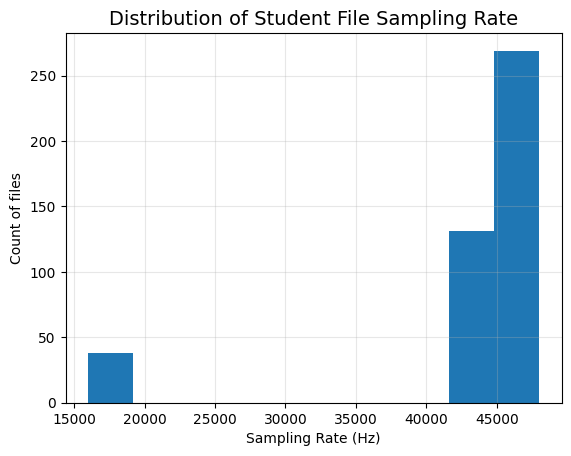

In [28]:
df.hist("sampling_rate")
plt.xlabel('Sampling Rate (Hz)')
plt.ylabel('Count of files')
plt.title('Distribution of Student File Sampling Rate', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 438 entries, 0 to 437
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   file_name      438 non-null    str    
 1   duration       438 non-null    float64
 2   sampling_rate  438 non-null    int64  
dtypes: float64(1), int64(1), str(1)
memory usage: 10.4 KB


In [30]:
df.sampling_rate.describe()

count      438.000000
mean     44057.305936
std       8833.039654
min      16000.000000
25%      44100.000000
50%      48000.000000
75%      48000.000000
max      48000.000000
Name: sampling_rate, dtype: float64

In [31]:
# Drop files with less than 44100 sampling rates
df = df[df['sampling_rate'] >= 44100]

In [32]:
df.sampling_rate.describe()

count      400.000000
mean     46722.750000
std       1832.567378
min      44100.000000
25%      44100.000000
50%      48000.000000
75%      48000.000000
max      48000.000000
Name: sampling_rate, dtype: float64

In [33]:
df.duration.describe()

count    400.000000
mean       2.940101
std        1.035806
min        1.015918
25%        2.250034
50%        2.766644
75%        3.400000
max        6.900000
Name: duration, dtype: float64

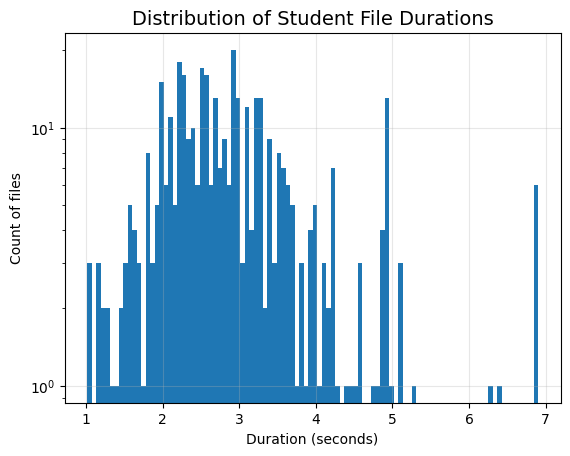

In [22]:
df.hist('duration', log=True, bins=100)
plt.xlabel('Duration (seconds)')
plt.ylabel('Count of files')
plt.title('Distribution of Student File Durations', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

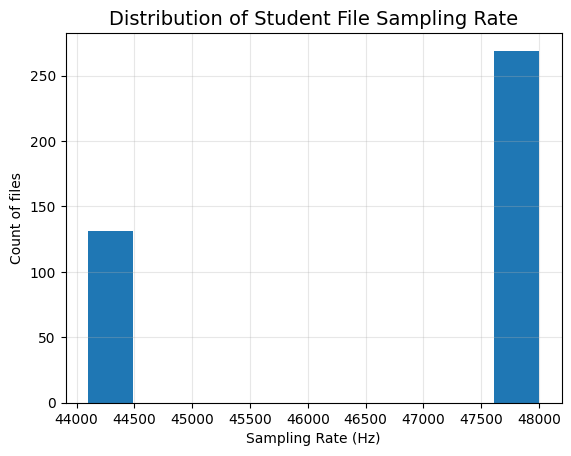

In [34]:
df.hist("sampling_rate")
plt.xlabel('Sampling Rate (Hz)')
plt.ylabel('Count of files')
plt.title('Distribution of Student File Sampling Rate', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

In [35]:
df

,file_name,duration,sampling_rate
0,E:\CREMA-D\student_audio\AContreras\0837_IEO_A...,6.900000,44100
1,E:\CREMA-D\student_audio\AContreras\0837_IEO_D...,6.900000,44100
2,E:\CREMA-D\student_audio\AContreras\0837_IEO_F...,4.900000,44100
3,E:\CREMA-D\student_audio\AContreras\0837_IEO_H...,4.900000,44100
4,E:\CREMA-D\student_audio\AContreras\0837_IEO_N...,4.800000,48000
...,...,...,...
433,E:\CREMA-D\student_audio\ZXue\9109_TSI_HAP_XX.wav,2.213537,44100
434,E:\CREMA-D\student_audio\ZXue\9109_TSI_NEU_XX.wav,2.026054,44100
435,E:\CREMA-D\student_audio\ZXue\9109_WSI_ANG_XX.wav,2.057302,44100
436,E:\CREMA-D\student_audio\ZXue\9109_WSI_HAP_XX.wav,2.338526,44100
